<a href="https://colab.research.google.com/github/pranathiperii/CRC-TGCA-Analysis/blob/main/CRC_TGCA_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving COAD_clinical.csv..csv to COAD_clinical.csv..csv
Saving COAD_methylation.csv.csv to COAD_methylation.csv.csv
Saving COAD_RNAseq.csv.csv to COAD_RNAseq.csv.csv


In [3]:
import pandas as pd
import numpy as np

rnaseq = pd.read_csv("COAD_RNAseq.csv.csv")
methylation = pd.read_csv("COAD_methylation.csv.csv")
clinical = pd.read_csv("COAD_clinical.csv..csv")

# Reshape to wide format
rnaseq_wide = rnaseq.pivot_table(index="case_barcode", columns="gene_name", values="expression")
methyl_wide = methylation.pivot_table(index="case_barcode", columns="probe_id", values="beta_value")

# Log2 transform expression
rnaseq_wide = np.log2(rnaseq_wide + 1)

# Merge all three
integrated = rnaseq_wide.join(methyl_wide, how="inner").join(
    clinical.set_index("case_barcode"), how="inner")

print(integrated.shape)
print(integrated.head())

(296, 59)
                   APC     AXIN2      BMP3      BRAF      CDH1    CDKN2A  \
case_barcode                                                               
TCGA-3L-AA1B  1.965212  7.217004  0.549817  1.366700  6.921496  1.309351   
TCGA-4N-A93T  1.789312  4.357876  0.039419  0.994145  7.121686  0.333538   
TCGA-4T-AA8H  1.982729  5.733623  0.365693  1.144177  6.413047  1.282736   
TCGA-5M-AAT4  1.942233  4.346035  0.015498  1.291309  6.359976  0.876802   
TCGA-5M-AAT5  1.910042  5.576162  0.023468  0.970191  7.326217  0.943809   

                  CDX2    CEACAM5    CTNNB1    CYP2B6  ...  cg02839557  \
case_barcode                                           ...               
TCGA-3L-AA1B  6.329708   9.908293  6.160553  4.405965  ...         NaN   
TCGA-4N-A93T  7.195640  10.858727  4.968234  2.588517  ...    0.018830   
TCGA-4T-AA8H  6.609601  10.696094  5.439603  2.779302  ...         NaN   
TCGA-5M-AAT4  6.490456  10.569546  4.654579  1.735046  ...    0.041746   
TCGA-5M-AAT5 

In [5]:
print(clinical.columns.tolist())

['case_barcode', 'gender', 'vital_status', 'days_to_death', 'age_at_diagnosis', 'project']


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare features and target
target = integrated["vital_status"].map({"Alive": 0, "Dead": 1})
features = integrated.drop(columns=["gender", "vital_status", "days_to_death",
                                      "age_at_diagnosis", "project"])
features = features.dropna(axis=1, thresh=int(0.8 * len(features)))
features = features.fillna(features.median())

# Align target and features
mask = target.notna()
X = features[mask]
y = target[mask]

print("Class distribution:"); print(y.value_counts())
print("Feature matrix shape:", X.shape)

Class distribution:
vital_status
0.0    224
1.0     70
Name: count, dtype: int64
Feature matrix shape: (294, 53)


In [7]:
from sklearn.utils import resample

# Balance classes by oversampling the minority
X_majority = X[y == 0]
y_majority = y[y == 0]
X_minority = X[y == 1]
y_minority = y[y == 1]

X_minority_upsampled, y_minority_upsampled = resample(
    X_minority, y_minority,
    replace=True, n_samples=len(X_majority),
    random_state=42)

X_balanced = pd.concat([X_majority, X_minority_upsampled])
y_balanced = pd.concat([y_majority, y_minority_upsampled])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Alive", "Dead"]))

              precision    recall  f1-score   support

       Alive       0.95      0.95      0.95        43
        Dead       0.96      0.96      0.96        47

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



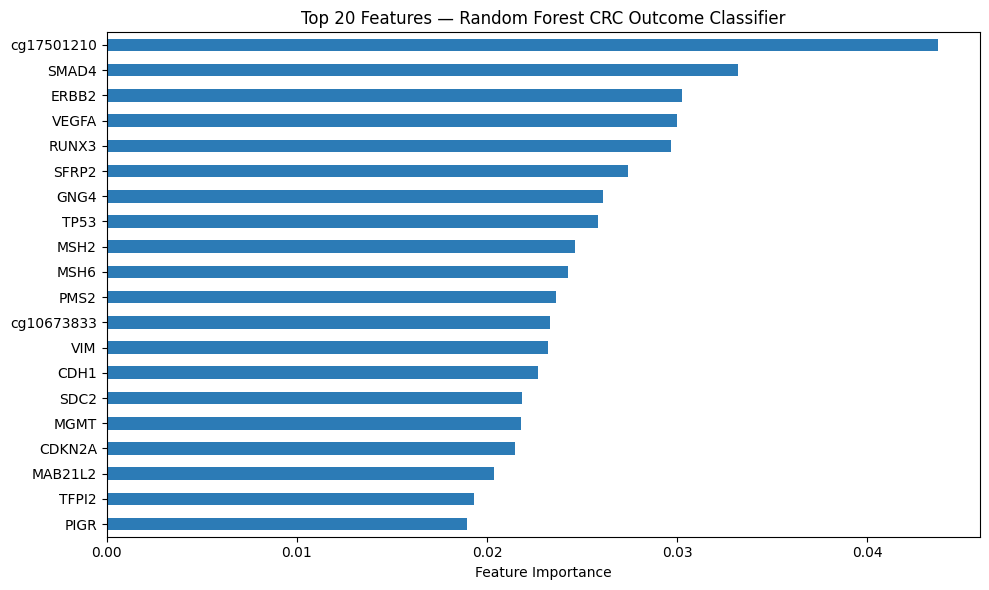

In [8]:
# Feature importance plot
importances = pd.Series(rf.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.plot(kind="barh", color="#2c7bb6")
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top 20 Features — Random Forest CRC Outcome Classifier")
plt.tight_layout()
plt.show()

In [9]:
print(classification_report(y_test, y_pred, target_names=["Alive", "Dead"]))

              precision    recall  f1-score   support

       Alive       0.95      0.95      0.95        43
        Dead       0.96      0.96      0.96        47

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Cross-validate on original unbalanced data - more honest evaluation
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")

cv_scores = cross_val_score(rf_cv, X, y, cv=5, scoring="roc_auc")

print("5-fold Cross-validated ROC-AUC scores:", cv_scores)
print(f"Mean AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

5-fold Cross-validated ROC-AUC scores: [0.62063492 0.54365079 0.49285714 0.48571429 0.38474026]
Mean AUC: 0.506 (+/- 0.077)


In [11]:
from google.colab import files
uploaded = files.upload()

Saving COAD_tumour_normal.csv to COAD_tumour_normal.csv


In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Load and reshape
tn = pd.read_csv("COAD_tumour_normal.csv")
tn_wide = tn.pivot_table(index=["case_barcode","sample_type_name"],
                          columns="gene_name", values="expression").reset_index()
tn_wide.iloc[:,2:] = np.log2(tn_wide.iloc[:,2:] + 1)
tn_wide = tn_wide.dropna()

# Target: tumour vs normal
y = (tn_wide["sample_type_name"] == "Primary Tumor").astype(int)
X = tn_wide.drop(columns=["case_barcode","sample_type_name"])

print("Class distribution:"); print(y.value_counts())
print("Shape:", X.shape)

Class distribution:
sample_type_name
1    458
0     41
Name: count, dtype: int64
Shape: (499, 38)


In [13]:
# Cross-validated AUC with balanced class weights
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="roc_auc",
                             cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

print("5-fold AUC scores:", cv_scores)
print(f"Mean AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Train on full data for feature importance
rf.fit(X, y)

# Plot feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(20)
plt.figure(figsize=(10,8))
importances.plot(kind="barh", color="#d7191c")
plt.title("Top 20 Features — Tumour vs Normal Classifier")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance_tumour_normal.png", dpi=300)
plt.show()

SyntaxError: keyword argument repeated: cv (3560919522.py, line 4)

5-fold AUC scores: [1. 1. 1. 1. 1.]
Mean AUC: 1.000 (+/- 0.000)


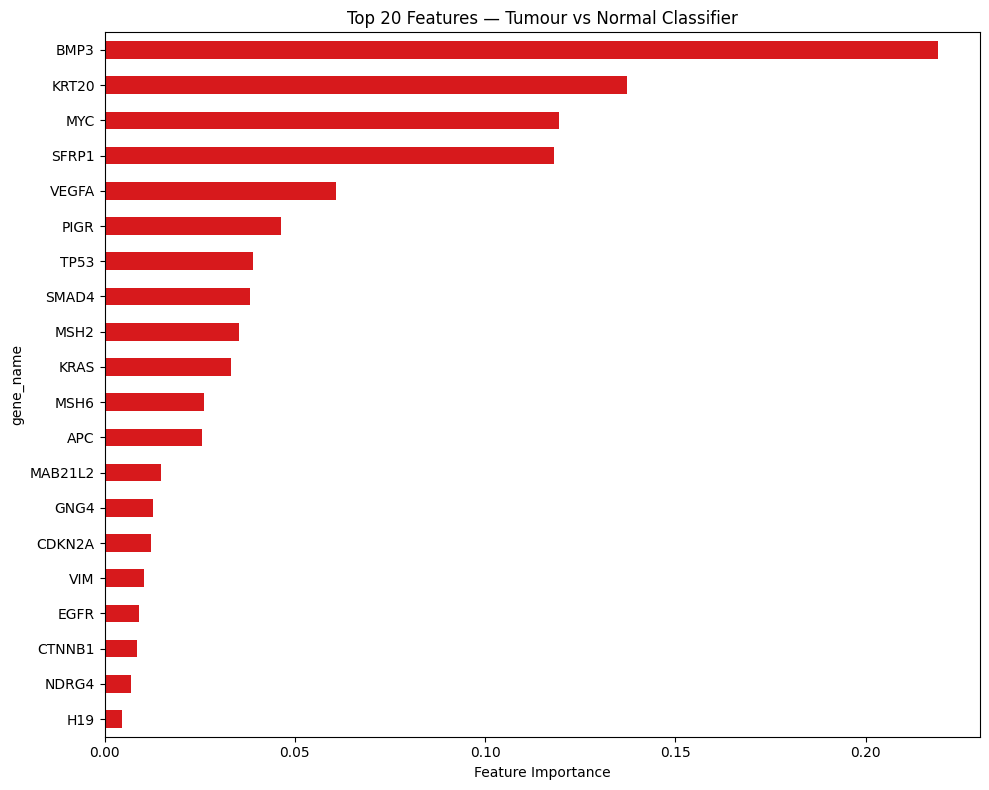

In [14]:
from sklearn.model_selection import StratifiedKFold

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=skf, scoring="roc_auc")

print("5-fold AUC scores:", cv_scores)
print(f"Mean AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(20)
plt.figure(figsize=(10,8))
importances.plot(kind="barh", color="#d7191c")
plt.title("Top 20 Features — Tumour vs Normal Classifier")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance_tumour_normal.png", dpi=300)
plt.show()
